In [ ]:
import pandas as pd
import numpy as np
from glob import glob
import statsmodels.api as sm
import statsmodels.formula.api as smf



In [ ]:
minute_path = "Data/EURUSD 1m/*"
eur_event_path = "Data/eur_events_backup.xlsx"
us_event_path = "Data/us_events_backup.xlsx"

PRICE_SOURCE_TZ = "America/New_York"
ANALYSIS_TZ = "Europe/Amsterdam"

In [ ]:
minute_files = sorted(glob(minute_path))

minute = pd.concat(
    [
        pd.read_csv(
            f,
            sep=";",
            header=None,
            names=["datetime", "open", "high", "low", "close", "volume"]
        )
        for f in minute_files
    ],
    ignore_index=True
)

minute["datetime"] = (
    pd.to_datetime(minute["datetime"])
    .dt.tz_localize(PRICE_SOURCE_TZ, ambiguous="NaT", nonexistent="shift_forward")
    .dt.tz_convert(ANALYSIS_TZ)
)
minute = minute[["datetime", "open", "high", "low", "close"]]
minute = minute.sort_values("datetime").reset_index(drop=True)

In [ ]:
def load_event_book(path, source):
    xls = pd.ExcelFile(path)
    parts = []
    print(xls.sheet_names)
    for sheet in ['cpi_yoy','NFP','cb_target_rate']:
        df = pd.read_excel(path, sheet_name=sheet)

        df["datetime_raw"] = pd.to_datetime(df["datetime"], errors="coerce")
        df["datetime"] = df["datetime_raw"].dt.tz_localize(
            ANALYSIS_TZ, ambiguous="NaT", nonexistent="shift_forward"
        )

        df["event_type"] = sheet
        df["source"] = source

        df = df[["datetime_raw", "datetime", "survey", "actual", "event_type", "source"]]
        parts.append(df)

    return pd.concat(parts, ignore_index=True)

# eur_events = load_event_book(eur_event_path, "EUR")
us_events = load_event_book(us_event_path, "US")

events = pd.concat([us_events], ignore_index=True)
events = events.sort_values("datetime").reset_index(drop=True)
events = events[events["datetime"].dt.year > 2008].copy()
events["event_type"] = events["event_type"].copy()

['cpi_yoy', 'unempl_rate', 'gdp', 'NFP', 'bus_cond', 'cb_target_rate']


In [ ]:
minute.head(), events.head(), minute.shape, events.shape

(                   datetime    open    high     low   close
 0 2000-05-30 23:27:00+02:00  0.9302  0.9302  0.9302  0.9302
 1 2000-05-30 23:35:00+02:00  0.9304  0.9305  0.9304  0.9305
 2 2000-05-30 23:38:00+02:00  0.9304  0.9304  0.9303  0.9303
 3 2000-05-30 23:43:00+02:00  0.9301  0.9301  0.9300  0.9300
 4 2000-05-30 23:44:00+02:00  0.9298  0.9298  0.9297  0.9297,
            datetime_raw                  datetime  survey  actual  \
 260 2009-01-09 14:30:00 2009-01-09 14:30:00+01:00 -525.00 -524.00   
 261 2009-01-16 14:30:00 2009-01-16 14:30:00+01:00   -0.20    0.10   
 262 2009-01-28 20:15:00 2009-01-28 20:15:00+01:00    0.25    0.25   
 263 2009-02-06 14:30:00 2009-02-06 14:30:00+01:00 -540.00 -598.00   
 264 2009-02-20 14:30:00 2009-02-20 14:30:00+01:00   -0.10    0.00   
 
          event_type source  
 260             NFP     US  
 261         cpi_yoy     US  
 262  cb_target_rate     US  
 263             NFP     US  
 264         cpi_yoy     US  ,
 (8720941, 5),
 (551, 6))

In [ ]:
events = events.dropna(subset=["datetime"]).copy()
events["event_id"] = np.arange(len(events))

START = 0
END = 16

offsets = pd.DataFrame({
    "rel_min": np.arange(START, END)
})

expected_bars = len(offsets)

event_minutes = events[["event_id", "datetime", "survey", "actual", "event_type", "source"]].merge(
    offsets, how="cross"
)

event_minutes["datetime"] = event_minutes["datetime"] + pd.to_timedelta(event_minutes["rel_min"], unit="m")

In [ ]:

windows = event_minutes.merge(
    minute,
    on="datetime",
    how="left"
).sort_values(["event_id", "datetime"]).reset_index(drop=True)

In [ ]:
coverage = windows.groupby("event_id")["close"].count().rename("n_bars")
events = events.merge(coverage, on="event_id", how="left")
events["complete_window"] = events["n_bars"] == expected_bars

events["complete_window"].value_counts()

complete_window
True     540
False     11
Name: count, dtype: int64

In [ ]:
valid_ids = events.loc[events["complete_window"], "event_id"]

events = events[events["event_id"].isin(valid_ids)].copy()
windows = windows[windows["event_id"].isin(valid_ids)].copy()

events = events.sort_values("event_id").reset_index(drop=True)
windows = windows.sort_values(["event_id", "datetime"]).reset_index(drop=True)

In [ ]:
windows["log_close"] = np.log(windows["close"])
windows["ret_1m"] = windows.groupby("event_id")["log_close"].diff()

windows["parkinson_1m"] = (np.log(windows["high"] / windows["low"]) ** 2) / (4 * np.log(2))

In [ ]:
# Parkison
def vol_proxy(group):
    return group["parkinson_1m"].sum()

# Max abs return
# def vol_proxy(group):
#     return group["ret_1m"].abs().max()

# sum of squared returns
# def vol_proxy(group):
#     return (group["ret_1m"] ** 2).sum()

In [ ]:
tmp = windows.groupby("event_id").apply(vol_proxy)
vol_proxy_event = tmp.to_frame("vol_proxy").reset_index()

events = events.merge(vol_proxy_event, on="event_id", how="left")

In [ ]:
events[["datetime", "event_type", "source", "vol_proxy"]].head()

,datetime,event_type,source,vol_proxy
0,2009-01-09 14:30:00+01:00,NFP,US,0.000031
1,2009-01-16 14:30:00+01:00,cpi_yoy,US,0.000002
2,2009-01-28 20:15:00+01:00,cb_target_rate,US,0.000024
3,2009-02-06 14:30:00+01:00,NFP,US,0.000013
4,2009-02-20 14:30:00+01:00,cpi_yoy,US,0.000002


In [ ]:
# Creating placebo events by shifting original events
day_shifts = pd.DataFrame({"day_shift": [-28, -21, -14, -7, 7, 14, 21, 28]})

placebos = events[["event_id", "datetime"]].merge(day_shifts, how="cross")
placebos["placebo_time"] = placebos["datetime"] + pd.to_timedelta(placebos["day_shift"], unit="D")
placebos["placebo_id"] = np.arange(len(placebos))

In [ ]:
# Drop unqualifying placebo events

event_times = events[["datetime"]].sort_values("datetime").rename(columns={"datetime": "event_time"})

prev_event = pd.merge_asof(
    placebos[["placebo_id", "placebo_time"]].sort_values("placebo_time"),
    event_times,
    left_on="placebo_time",
    right_on="event_time",
    direction="backward"
).rename(columns={"event_time": "prev_event"})

next_event = pd.merge_asof(
    placebos[["placebo_id", "placebo_time"]].sort_values("placebo_time"),
    event_times,
    left_on="placebo_time",
    right_on="event_time",
    direction="forward"
).rename(columns={"event_time": "next_event"})

placebos = placebos.merge(prev_event, on=["placebo_id", "placebo_time"], how="left")
placebos = placebos.merge(next_event, on=["placebo_id", "placebo_time"], how="left")

placebos["dist_prev"] = (placebos["placebo_time"] - placebos["prev_event"]).dt.total_seconds().abs() / 60
placebos["dist_next"] = (placebos["placebo_time"] - placebos["next_event"]).dt.total_seconds().abs() / 60
placebos["nearest_event_min"] = placebos[["dist_prev", "dist_next"]].min(axis=1)

placebos = placebos[(placebos["nearest_event_min"].isna()) | (placebos["nearest_event_min"] > 60)].copy()

In [ ]:
# Build placebo windows

placebo_minutes = placebos[["placebo_id", "event_id", "placebo_time"]].merge(offsets, how="cross")
placebo_minutes["datetime"] = placebo_minutes["placebo_time"] + pd.to_timedelta(placebo_minutes["rel_min"], unit="m")

placebo_windows = placebo_minutes.merge(
    minute,
    on="datetime",
    how="left"
).sort_values(["placebo_id", "datetime"]).reset_index(drop=True)

In [ ]:
# Keep only complete placebo windows

placebo_coverage = placebo_windows.groupby("placebo_id")["close"].count().rename("n_bars").reset_index()

placebos = placebos.merge(placebo_coverage, on="placebo_id", how="left")
placebos = placebos[placebos["n_bars"] == expected_bars].copy()

placebo_windows = placebo_windows[placebo_windows["placebo_id"].isin(placebos["placebo_id"])].copy()
placebo_windows = placebo_windows.sort_values(["placebo_id", "datetime"]).reset_index(drop=True)

In [ ]:
# Calc placebo RV and Parkinson
 
placebo_windows["log_close"] = np.log(placebo_windows["close"])
placebo_windows["ret_1m"] = placebo_windows.groupby("placebo_id")["log_close"].diff()

placebo_windows["parkinson_1m"] = (np.log(placebo_windows["high"] / placebo_windows["low"]) ** 2) / (4 * np.log(2))

In [ ]:
# Collapse placebo windows to one row each

tmp = placebo_windows.groupby("placebo_id").apply(vol_proxy)
placebo_proxy = tmp.to_frame("vol_proxy_base").reset_index()

placebo_proxy = placebos[["placebo_id", "event_id"]].merge(
    placebo_proxy, on="placebo_id", how="left"
)

In [ ]:
baseline = placebo_proxy.groupby("event_id").agg(
    vol_proxy_base=("vol_proxy_base", "median"),
    n_placebos=("placebo_id", "size")
).reset_index()

events = events.merge(baseline, on="event_id", how="left")

In [ ]:
events["abn_vol_proxy"] = np.log(events["vol_proxy"]) - np.log(events["vol_proxy_base"])

In [ ]:
events[["datetime", "event_type", "vol_proxy", "vol_proxy_base", "abn_vol_proxy", "n_placebos"]].head()

,datetime,event_type,vol_proxy,vol_proxy_base,abn_vol_proxy,n_placebos
0,2009-01-09 14:30:00+01:00,NFP,0.000031,0.000002,2.809076,6
1,2009-01-16 14:30:00+01:00,cpi_yoy,0.000002,0.000002,0.100308,6
2,2009-01-28 20:15:00+01:00,cb_target_rate,0.000024,0.000001,2.928363,7
3,2009-02-06 14:30:00+01:00,NFP,0.000013,0.000003,1.423517,4
4,2009-02-20 14:30:00+01:00,cpi_yoy,0.000002,0.000002,-0.083592,6


In [ ]:
events = events.dropna(subset=["vol_proxy_base"]).copy()
events = events[events["n_placebos"] >= 3].reset_index(drop=True)

In [ ]:
events[["n_placebos"]].describe(), len(events)

(       n_placebos
 count  540.000000
 mean     6.796296
 std      1.208806
 min      3.000000
 25%      6.000000
 50%      7.000000
 75%      8.000000
 max      8.000000,
 540)

In [ ]:
events["n_placebos"].value_counts().sort_index()

n_placebos
3      6
4     24
5     48
6    112
7    156
8    194
Name: count, dtype: int64

In [ ]:
events[["vol_proxy", "vol_proxy_base", "abn_vol_proxy"]].describe()

,vol_proxy,vol_proxy_base,abn_vol_proxy
count,5.400000e+02,5.400000e+02,540.000000
mean,7.302103e-06,5.551998e-07,2.412024
std,1.026719e-05,5.527641e-07,1.358411
min,2.398082e-08,1.757188e-08,-3.486658
25%,1.903821e-06,1.903024e-07,1.534962
50%,4.536489e-06,3.607773e-07,2.410173
75%,9.199987e-06,6.774869e-07,3.366590
max,1.513552e-04,3.248990e-06,6.261324


In [ ]:
# Calculate surprise per event
events["surprise"] = events["actual"] - events["survey"]

In [ ]:
# Keep events with non-missing surprise
test = events.dropna(subset=["surprise"]).copy()

In [ ]:
group = test.groupby(["source", "event_type"])["surprise"]
surprise_mu = group.transform("mean")
surprise_sd = group.transform("std")

test["abs_z_surprise"] = ((test["surprise"] - surprise_mu) / surprise_sd).abs()

In [ ]:
test = test.replace([np.inf, -np.inf], np.nan)
test = test.dropna(subset=["abs_z_surprise"]).copy()

In [ ]:
test[["abs_z_surprise", "abn_vol_proxy"]].corr()

,abs_z_surprise,abn_vol_proxy
abs_z_surprise,1.000000,-0.102429
abn_vol_proxy,-0.102429,1.000000


In [ ]:
# Most basic regression, would be surprised if anything comes out of it

X = sm.add_constant(test["abs_z_surprise"])

model = sm.OLS(test["abn_vol_proxy"], X).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          abn_vol_proxy   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.170
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.280
Time:                        11:58:36   Log-Likelihood:                -926.60
No. Observations:                 539   AIC:                             1857.
Df Residuals:                     537   BIC:                             1866.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.4755      0.073     33.

In [ ]:
# Regressing announcement against the volatility, expected: high beta

real_reg = events[["event_id", "vol_proxy"]].copy()
real_reg["is_announcement"] = 1
real_reg["log_vol_proxy"] = np.log(real_reg["vol_proxy"])

placebo_reg = placebo_proxy[placebo_proxy["event_id"].isin(events["event_id"])][["event_id", "vol_proxy_base"]].copy()
placebo_reg["is_announcement"] = 0
placebo_reg["log_vol_proxy"] = np.log(placebo_reg["vol_proxy_base"])

reg_panel = pd.concat([
    real_reg[["event_id", "is_announcement", "log_vol_proxy"]],
    placebo_reg[["event_id", "is_announcement", "log_vol_proxy"]],
], ignore_index=True)

reg_panel = reg_panel.replace([np.inf, -np.inf], np.nan).dropna(subset=["log_vol_proxy"]).copy()

model = smf.ols(
    "log_vol_proxy ~ is_announcement + C(event_id)",
    data=reg_panel
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_panel["event_id"]}
)

print(model.summary())

beta = model.params["is_announcement"]
print(f"\nBeta on is_announcement: {beta:.4f}")
print(f"Vol multiple: {np.exp(beta):.2f}x")
print(f"Pct effect: {(np.exp(beta) - 1) * 100:.2f}%")

                            OLS Regression Results                            
Dep. Variable:          log_vol_proxy   R-squared:                       0.570
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                 1.406e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:58:37   Log-Likelihood:                -5892.6
No. Observations:                4210   AIC:                         1.287e+04
Df Residuals:                    3669   BIC:                         1.630e+04
Df Model:                         540                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            -13.1043      0

c:\Users\AXZO\Documents\Code\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 540, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# Robustness: winsorized dependent variable (1st / 99th percentiles)

lo = reg_panel["log_vol_proxy"].quantile(0.01)
hi = reg_panel["log_vol_proxy"].quantile(0.99)

reg_panel["log_vol_proxy_win"] = reg_panel["log_vol_proxy"].clip(lower=lo, upper=hi)

print(f"Winsorization bounds: [{lo:.4f}, {hi:.4f}]")

model_win = smf.ols(
    "log_vol_proxy_win ~ is_announcement + C(event_id)",
    data=reg_panel
).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_panel["event_id"]}
)

print(model_win.summary())

beta_win = model_win.params["is_announcement"]
se_win = model_win.bse["is_announcement"]

print(f"\nWinsorized beta on is_announcement: {beta_win:.4f}")
print(f"Winsorized SE: {se_win:.4f}")
print(f"Winsorized vol multiple: {np.exp(beta_win):.2f}x")
print(f"Winsorized pct effect: {(np.exp(beta_win) - 1) * 100:.2f}%")

Winsorization bounds: [-17.6095, -10.9214]
                            OLS Regression Results                            
Dep. Variable:      log_vol_proxy_win   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                 1.382e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:58:38   Log-Likelihood:                -5832.8
No. Observations:                4210   AIC:                         1.275e+04
Df Residuals:                    3669   BIC:                         1.618e+04
Df Model:                         540                                         
Covariance Type:              cluster                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

c:\Users\AXZO\Documents\Code\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 540, but rank is 1
  warnings.warn('covariance of constraints does not have full '


Text(0.5, 1.0, 'Binned relation: surprise vs abnormal volatility')

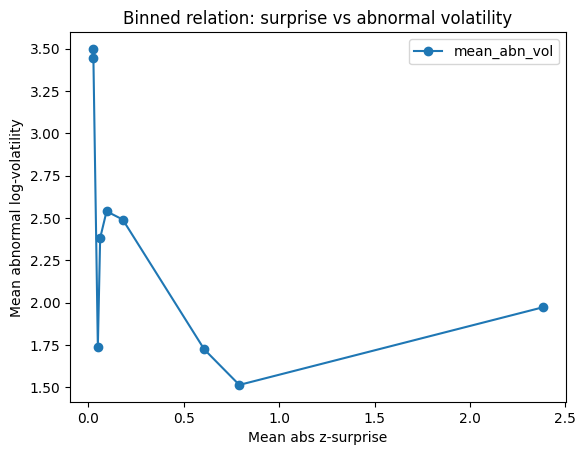

In [ ]:
plot_df = test[["abs_z_surprise", "abn_vol_proxy"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
plot_df["surprise_bin"] = pd.qcut(plot_df["abs_z_surprise"], q=10, duplicates="drop")

bin_means = plot_df.groupby("surprise_bin", observed=True).agg(
    mean_surprise=("abs_z_surprise", "mean"),
    mean_abn_vol=("abn_vol_proxy", "mean")
).reset_index(drop=True)

ax = bin_means.plot(x="mean_surprise", y="mean_abn_vol", marker="o")
ax.set_xlabel("Mean abs z-surprise")
ax.set_ylabel("Mean abnormal log-volatility")
ax.set_title("Binned relation: surprise vs abnormal volatility")

In [ ]:
# Add event type and source dummies

model = smf.ols(
    "abn_vol_proxy ~ abs_z_surprise + C(event_type)",
    data=test
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          abn_vol_proxy   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     98.62
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           8.04e-51
Time:                        11:17:17   Log-Likelihood:                -791.86
No. Observations:                 539   AIC:                             1592.
Df Residuals:                     535   BIC:                             1609.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [ ]:

model = smf.ols(
    "abn_vol_proxy ~ abs_z_surprise * C(event_type)",
    data=test
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          abn_vol_proxy   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     60.73
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           4.78e-50
Time:                        12:09:21   Log-Likelihood:                -789.82
No. Observations:                 539   AIC:                             1592.
Df Residuals:                     533   BIC:                             1617.
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

Include state awareness

In [ ]:
PRE_START = 35
PRE_END = -1

pre_offsets = pd.DataFrame({
    "rel_min": np.arange(PRE_START, PRE_END)
})

pre_expected_bars = len(pre_offsets)

pre_minutes = events[["event_id", "datetime"]].merge(pre_offsets, how="cross")
pre_minutes["datetime"] = pre_minutes["datetime"] + pd.to_timedelta(pre_minutes["rel_min"], unit="m")

pre_windows = pre_minutes.merge(
    minute,
    on="datetime",
    how="left"
).sort_values(["event_id", "datetime"]).reset_index(drop=True)

In [ ]:
pre_windows["log_close"] = np.log(pre_windows["close"])
pre_windows["ret_1m"] = pre_windows.groupby("event_id")["log_close"].diff()
pre_windows["parkinson_1m"] = (
    (np.log(pre_windows["high"]) - np.log(pre_windows["low"])) ** 2
) / (4 * np.log(2))

In [ ]:
pre_coverage = pre_windows.groupby("event_id")["close"].count().rename("pre_n_bars")
events = events.merge(pre_coverage, on="event_id", how="left")

valid_pre_ids = events.loc[events["pre_n_bars"] == pre_expected_bars, "event_id"]
pre_windows = pre_windows[pre_windows["event_id"].isin(valid_pre_ids)].copy()
events = events[events["event_id"].isin(valid_pre_ids)].copy()

In [ ]:
tmp = pre_windows.groupby("event_id").apply(vol_proxy)
pre_state = tmp.to_frame("pre_event_rv").reset_index()

events = events.merge(pre_state, on="event_id", how="left")
events["log_pre_event_rv"] = np.log(events["pre_event_rv"])